# 📊 Análisis Exploratorio — Clasificador de Sentimientos en Español


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import warnings
import sys
import os

sys.path.insert(0, os.path.abspath(".."))
from src.datos import cargar_datos
from src.preprocesar import preprocesar_serie, tokens_a_texto

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = cargar_datos("Datos/IMDB Dataset Spanish.csv")
print(df.shape)
df.head(3)

(49599, 2)


,texto,etiqueta
0,Uno de los otros críticos ha mencionado que de...,1
1,Una pequeña pequeña producción.La técnica de f...,1
2,Pensé que esta era una manera maravillosa de p...,1


## 1. Distribución de clases

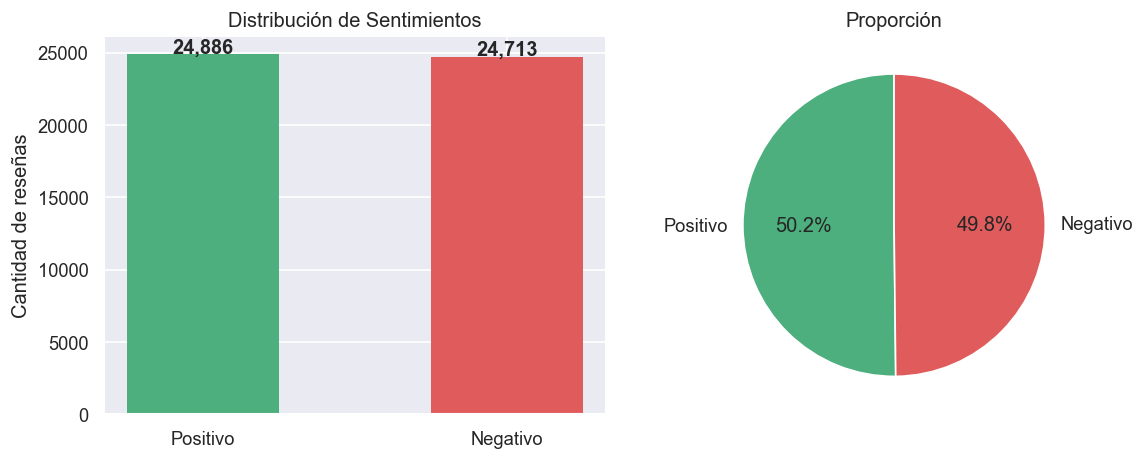

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

conteo = df["etiqueta"].value_counts()
labels = ["Positivo", "Negativo"]
colors = ["#4caf7d", "#e05c5c"]

# Barras
axes[0].bar(labels, [conteo[1], conteo[0]], color=colors, edgecolor="none", width=0.5)
axes[0].set_title("Distribución de Sentimientos")
axes[0].set_ylabel("Cantidad de reseñas")
for i, v in enumerate([conteo[1], conteo[0]]):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

# Pie
axes[1].pie(
    [conteo[1], conteo[0]],
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Proporción")

plt.tight_layout()
plt.savefig("Resultados/eda_distribucion.png")
plt.show()

## 2. Longitud de las reseñas

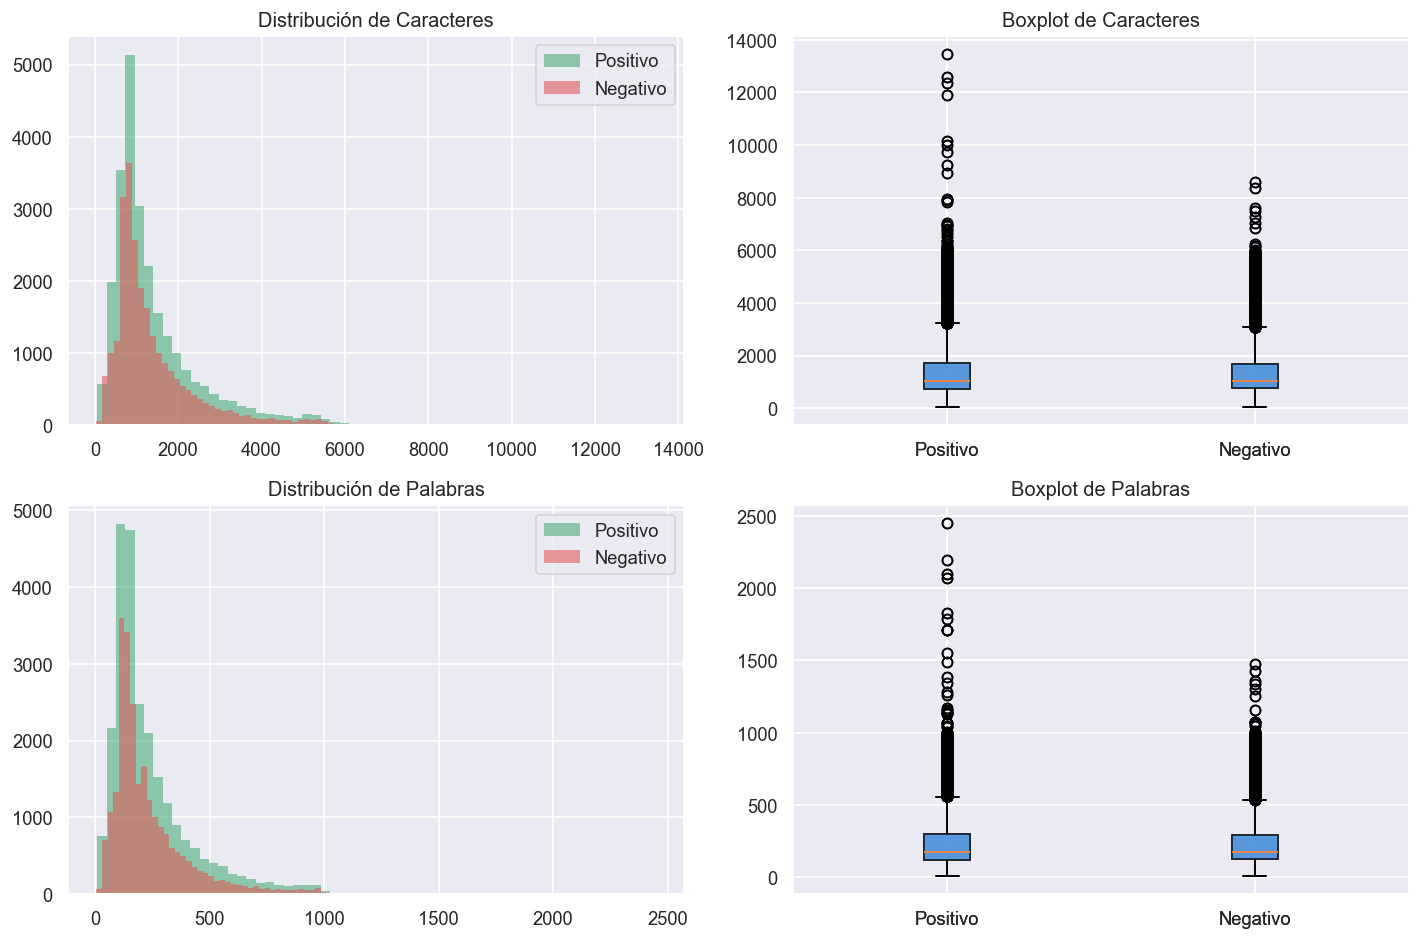

         num_chars                                                        \
             count    mean     std   min    25%     50%     75%      max   
etiqueta                                                                   
0          24713.0  1383.4   994.6  39.0  756.0  1041.0  1686.0   8587.0   
1          24886.0  1414.9  1080.3  64.0  739.0  1033.0  1736.8  13465.0   

         num_palabras                                                   
                count   mean    std   min    25%    50%    75%     max  
etiqueta                                                                
0             24713.0  235.1  172.7   6.0  125.0  173.0  290.0  1474.0  
1             24886.0  239.8  186.3  10.0  122.0  172.0  297.0  2450.0  


In [6]:
df["num_chars"] = df["texto"].str.len()
df["num_palabras"] = df["texto"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, (col, titulo) in enumerate(
    [("num_chars", "Caracteres"), ("num_palabras", "Palabras")]
):
    for etiqueta, color, nombre in [
        (1, "#4caf7d", "Positivo"),
        (0, "#e05c5c", "Negativo"),
    ]:
        datos = df[df["etiqueta"] == etiqueta][col]
        axes[idx][0].hist(
            datos, bins=60, alpha=0.6, color=color, label=nombre, edgecolor="none"
        )
        axes[idx][1].boxplot(
            [df[df["etiqueta"] == 1][col], df[df["etiqueta"] == 0][col]],
            labels=["Positivo", "Negativo"],
            patch_artist=True,
            boxprops=dict(facecolor="#4a90d9", alpha=0.7),
        )
    axes[idx][0].set_title(f"Distribución de {titulo}")
    axes[idx][0].legend()
    axes[idx][1].set_title(f"Boxplot de {titulo}")

plt.tight_layout()
plt.savefig("Resultados/eda_longitud.png")
plt.show()

print(df.groupby("etiqueta")[["num_chars", "num_palabras"]].describe().round(1))

## 3. Preprocesamiento y tokenización (muestra de 5,000 reseñas para EDA)

In [7]:
# Usamos muestra para el EDA (el preprocesamiento completo se hace en entrenamiento.py)
muestra = df.sample(5000, random_state=42).copy()
muestra["tokens"] = preprocesar_serie(muestra["texto"])
muestra["texto_limpio"] = muestra["tokens"].apply(tokens_a_texto)
muestra["num_tokens"] = muestra["tokens"].str.len()
print("Tokens promedio por reseña:", muestra["num_tokens"].mean().round(1))
muestra[["texto", "tokens", "num_tokens"]].head(3)

Preprocesando: 100%|██████████| 5000/5000 [02:44<00:00, 30.44it/s]

Tokens promedio por reseña: 100.8


,texto,tokens,num_tokens
33392,"Dos años después del éxito de 'avión', Jim Abr...","[año, éxito, avión, jim, abrahams, jerry, davi...",94
6543,"He leído los comentarios de KERCHING ON IMDB, ...","[leer, comentario, kerching, imdb, francamente...",79
8235,"Una historia sobre el amor y el odio, la trage...","[historia, amor, odio, tragedia, felicidad, am...",50


## 4. Palabras más frecuentes por clase

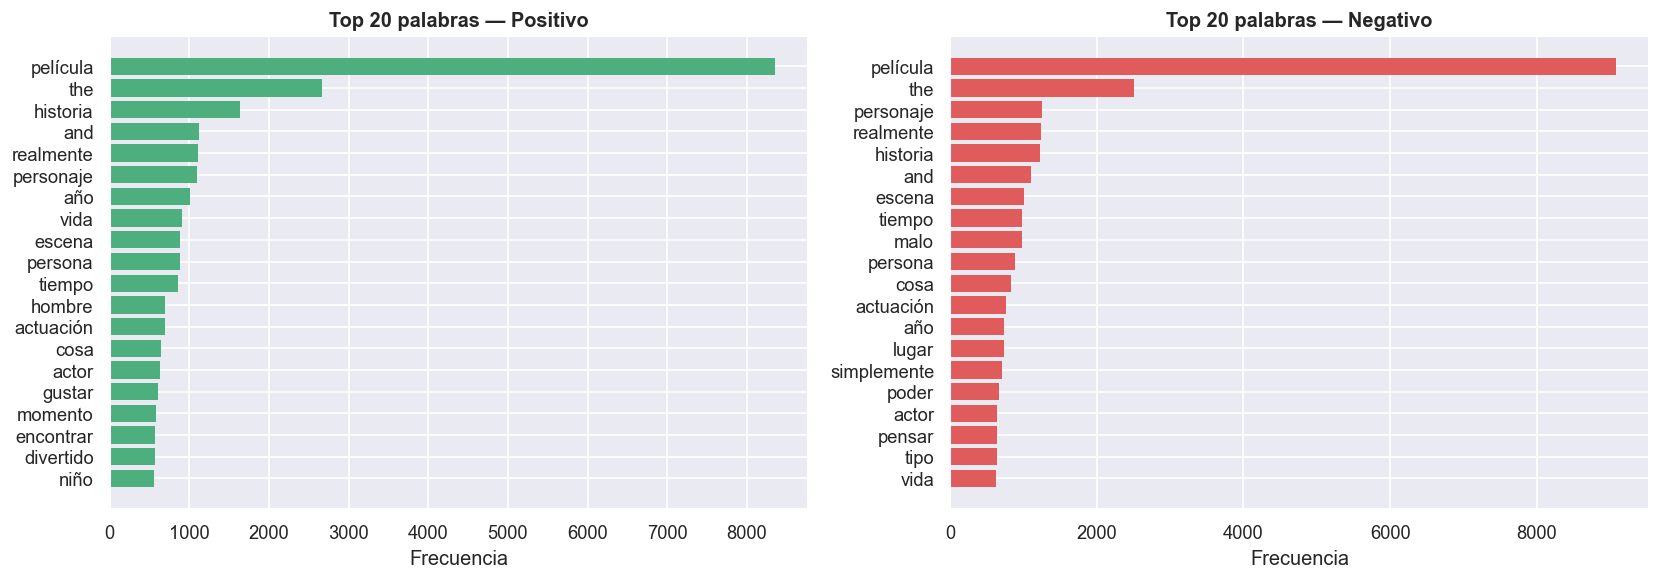

In [8]:
def top_palabras(df_sub, n=20):
    todas = [token for tokens in df_sub["tokens"] for token in tokens]
    return Counter(todas).most_common(n)


top_pos = top_palabras(muestra[muestra["etiqueta"] == 1])
top_neg = top_palabras(muestra[muestra["etiqueta"] == 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top, titulo, color in [
    (axes[0], top_pos, "Top 20 palabras — Positivo", "#4caf7d"),
    (axes[1], top_neg, "Top 20 palabras — Negativo", "#e05c5c"),
]:
    palabras, conteos = zip(*top)
    ax.barh(palabras[::-1], conteos[::-1], color=color, edgecolor="none")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Frecuencia")

plt.tight_layout()
plt.savefig("Resultados/eda_top_palabras.png")
plt.show()

## 5. Nube de palabras

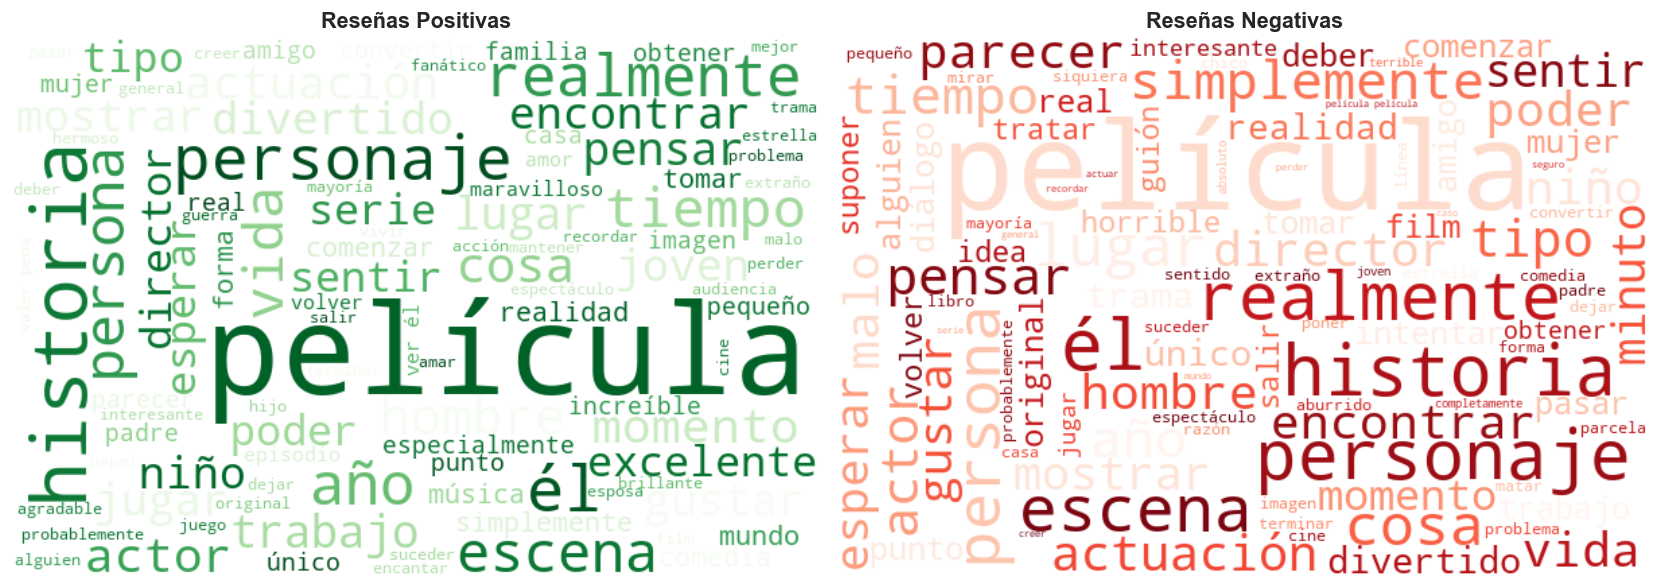

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, etiqueta, titulo, colormap in [
    (axes[0], 1, "Reseñas Positivas", "Greens"),
    (axes[1], 0, "Reseñas Negativas", "Reds"),
]:
    texto_unido = " ".join(muestra[muestra["etiqueta"] == etiqueta]["texto_limpio"])
    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=100,
    ).generate(texto_unido)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(titulo, fontweight="bold", fontsize=13)

plt.tight_layout()
plt.savefig("Resultados/eda_wordcloud.png")
plt.show()

## 6. N-gramas más frecuentes (bigramas)

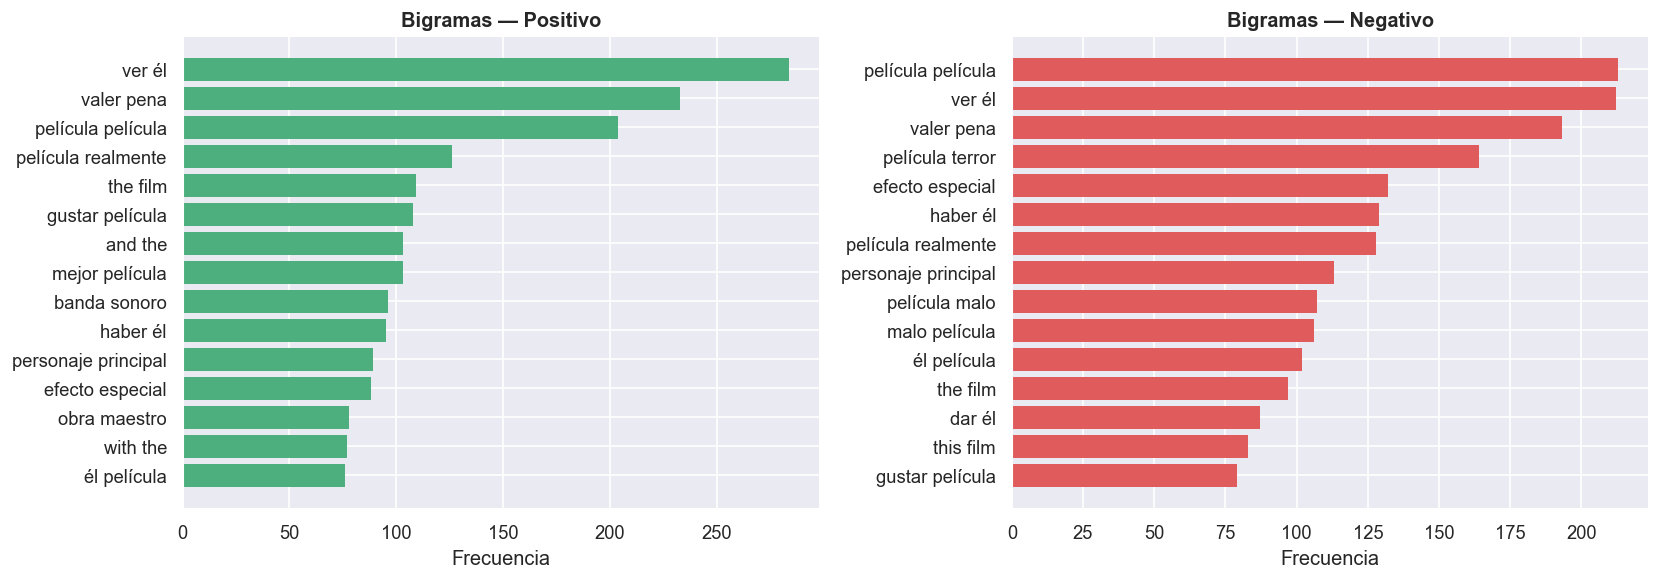

In [11]:
def top_ngramas(df_sub, n=2, top_n=15):
    vec = CountVectorizer(ngram_range=(n, n), max_features=top_n)
    vec.fit(df_sub["texto_limpio"])
    X = vec.transform(df_sub["texto_limpio"])
    conteos = X.toarray().sum(axis=0)
    return sorted(zip(vec.get_feature_names_out(), conteos), key=lambda x: -x[1])


bi_pos = top_ngramas(muestra[muestra["etiqueta"] == 1])
bi_neg = top_ngramas(muestra[muestra["etiqueta"] == 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, bi, titulo, color in [
    (axes[0], bi_pos, "Bigramas — Positivo", "#4caf7d"),
    (axes[1], bi_neg, "Bigramas — Negativo", "#e05c5c"),
]:
    palabras, conteos = zip(*bi)
    ax.barh(palabras[::-1], conteos[::-1], color=color, edgecolor="none")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Frecuencia")

plt.tight_layout()
plt.savefig("Resultados/eda_bigramas.png")
plt.show()

## 7. Vocabulario único por clase

Vocabulario positivo:     31,565 palabras
Vocabulario negativo:     30,729 palabras
Exclusivo positivo:       15,320 palabras
Exclusivo negativo:       14,484 palabras
Compartido entre clases:  16,245 palabras


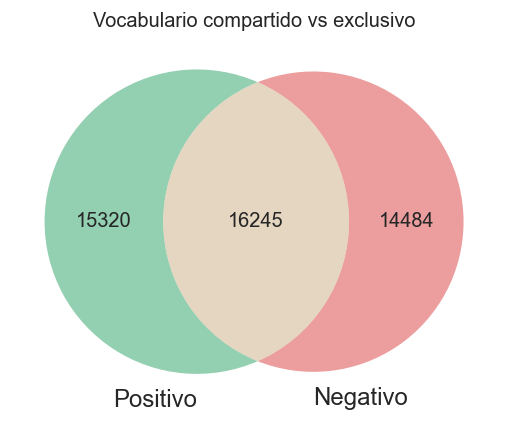

In [12]:
vocab_pos = set(
    t for tokens in muestra[muestra["etiqueta"] == 1]["tokens"] for t in tokens
)
vocab_neg = set(
    t for tokens in muestra[muestra["etiqueta"] == 0]["tokens"] for t in tokens
)

exclusivo_pos = vocab_pos - vocab_neg
exclusivo_neg = vocab_neg - vocab_pos
compartido = vocab_pos & vocab_neg

print(f"Vocabulario positivo:     {len(vocab_pos):,} palabras")
print(f"Vocabulario negativo:     {len(vocab_neg):,} palabras")
print(f"Exclusivo positivo:       {len(exclusivo_pos):,} palabras")
print(f"Exclusivo negativo:       {len(exclusivo_neg):,} palabras")
print(f"Compartido entre clases:  {len(compartido):,} palabras")

# Venn diagram simple
from matplotlib_venn import venn2

plt.figure(figsize=(6, 4))
venn2(
    [vocab_pos, vocab_neg],
    set_labels=("Positivo", "Negativo"),
    set_colors=("#4caf7d", "#e05c5c"),
    alpha=0.6,
)
plt.title("Vocabulario compartido vs exclusivo")
plt.savefig("Resultados/eda_venn.png")
plt.show()